# 🎓 Retenza - Student Dropout Risk Prediction

This notebook explores the Machine Learning pipeline (Random Forest) for the Retenza dropout prediction system. It includes data synthesis, model training, evaluation metrics, and the prediction engine logic from the Flask backend.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='darkgrid')

## 1. Feature Definition
Defining the predictive features utilized by the model to determine student dropout risk.

In [2]:
FEATURES = [
    'completion_rate_1', 'completion_rate_2',
    'approved_1sem',     'approved_2sem',
    'grade_1sem',        'grade_2sem',
    'tuition_fees',      'financial_risk',
    'scholarship',       'debt',
    'attendance',        'study_hrs',
    'exam_prep',         'employed',
    'childcare',         'displaced',
    'age',
]

FEATURE_DISPLAY_NAMES = {
    'completion_rate_2': 'Completion Rate (Sem 2)',
    'completion_rate_1': 'Completion Rate (Sem 1)',
    'approved_2sem':     'Approved Courses (Sem 2)',
    'grade_2sem':        'Average Grades (Sem 2)',
    'grade_1sem':        'Average Grades (Sem 1)',
    'financial_risk':    'Financial Risk',
    'tuition_fees':      'Tuition Fees Status',
    'attendance':        'Class Attendance',
    'approved_1sem':     'Approved Courses (Sem 1)',
    'study_hrs':         'Weekly Study Hours',
    'age':               'Age of Enrollment',
    'scholarship':       'Scholarship Holder',
    'exam_prep':         'Exam Prep Level',
    'employed':          'Employment Status',
    'debt':              'Outstanding Debt',
    'childcare':         'Childcare Responsibilities',
    'displaced':         'Displaced / Refugee Status',
}

## 2. Synthetic Data Generation
Generating a realistic 3,630-record dataset. Dropouts and Current/Graduated students are modeled with distinct multi-variate statistical distributions representing known real-world patterns.

In [3]:
def generate_training_data(n_total: int = 3630, dropout_rate: float = 0.3915, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n_out = int(n_total * dropout_rate)   # ~1421 dropouts
    n_in  = n_total - n_out               # ~2209 enrolled

    def make_class(n, dropout: bool) -> pd.DataFrame:
        if dropout:
            cr1  = np.clip(rng.beta(2,   5,   n), 0.0, 1.0)
            cr2  = np.clip(rng.beta(1.5, 5,   n), 0.0, 1.0)
            ap1  = np.clip(rng.poisson(2.0, n),   0, 8)
            ap2  = np.clip(rng.poisson(1.5, n),   0, 8)
            g1   = np.clip(rng.normal(9.0, 3.0, n),  0, 20)
            g2   = np.clip(rng.normal(8.0, 3.0, n),  0, 20)
            tuit = rng.binomial(1, 0.25, n)
            finr = rng.binomial(1, 0.55, n)
            sch  = rng.binomial(1, 0.10, n)
            debt = rng.binomial(1, 0.50, n)
            att  = rng.choice([1,2,3,4], n, p=[0.35,0.35,0.20,0.10])
            stdy = rng.choice([1,2,3,4], n, p=[0.40,0.35,0.18,0.07])
            exam = rng.choice([1,2,3],   n, p=[0.50,0.35,0.15])
            emp  = rng.choice([0,1,2],   n, p=[0.25,0.40,0.35])
            chld = rng.binomial(1, 0.30, n)
            disp = rng.binomial(1, 0.15, n)
            age  = np.clip(rng.normal(26, 7, n), 17, 60)
        else:
            cr1  = np.clip(rng.beta(8, 2, n),   0.0, 1.0)
            cr2  = np.clip(rng.beta(8, 2, n),   0.0, 1.0)
            ap1  = np.clip(rng.poisson(5, n)+2,  0, 8)
            ap2  = np.clip(rng.poisson(5, n)+2,  0, 8)
            g1   = np.clip(rng.normal(14.0, 2.5, n), 0, 20)
            g2   = np.clip(rng.normal(14.0, 2.5, n), 0, 20)
            tuit = rng.binomial(1, 0.88, n)
            finr = rng.binomial(1, 0.10, n)
            sch  = rng.binomial(1, 0.35, n)
            debt = rng.binomial(1, 0.10, n)
            att  = rng.choice([1,2,3,4], n, p=[0.05,0.15,0.40,0.40])
            stdy = rng.choice([1,2,3,4], n, p=[0.05,0.20,0.45,0.30])
            exam = rng.choice([1,2,3],   n, p=[0.10,0.40,0.50])
            emp  = rng.choice([0,1,2],   n, p=[0.55,0.35,0.10])
            chld = rng.binomial(1, 0.10, n)
            disp = rng.binomial(1, 0.05, n)
            age  = np.clip(rng.normal(21, 3, n), 17, 40)

        return pd.DataFrame({
            'completion_rate_1': cr1, 'completion_rate_2': cr2,
            'approved_1sem': ap1.astype(int), 'approved_2sem': ap2.astype(int),
            'grade_1sem': g1, 'grade_2sem': g2,
            'tuition_fees': tuit, 'financial_risk': finr,
            'scholarship': sch, 'debt': debt,
            'attendance': att, 'study_hrs': stdy,
            'exam_prep': exam, 'employed': emp,
            'childcare': chld, 'displaced': disp,
            'age': age,
            'dropout': int(dropout),
        })

    df = pd.concat([make_class(n_out, True), make_class(n_in, False)], ignore_index=True)
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

df = generate_training_data()
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (3630, 18)


,completion_rate_1,completion_rate_2,approved_1sem,approved_2sem,grade_1sem,grade_2sem,tuition_fees,financial_risk,scholarship,debt,attendance,study_hrs,exam_prep,employed,childcare,displaced,age,dropout
0,0.114262,0.057398,1,3,11.128497,10.847802,0,1,0,1,2,1,1,0,0,0,27.839428,1
1,0.768975,0.713783,6,4,14.194618,10.908470,1,0,0,0,4,3,2,0,0,0,21.566584,0
2,0.184257,0.103475,0,1,7.707546,9.832073,0,1,0,0,2,2,1,1,0,0,33.265569,1
3,0.037855,0.502326,1,3,4.366161,8.209441,0,1,0,1,4,1,3,0,0,0,40.549829,1
4,0.917256,0.704448,7,7,20.000000,14.911279,1,0,1,0,3,3,2,0,1,0,17.657681,0


## 3. Exploratory Data Analysis
Let's visualize the class distribution and some key feature differences.

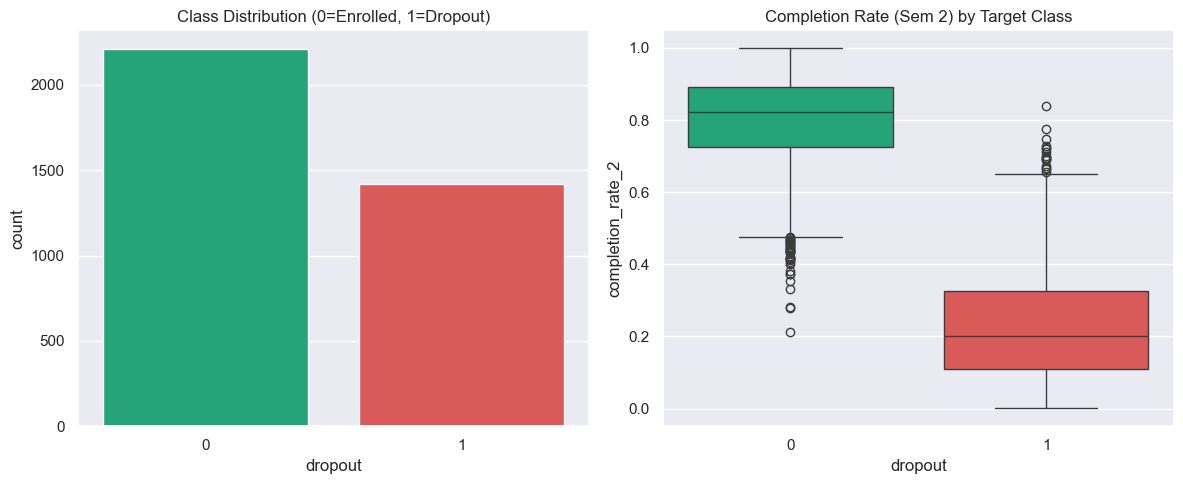

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='dropout', palette=['#10b981', '#ef4444'])
plt.title('Class Distribution (0=Enrolled, 1=Dropout)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='dropout', y='completion_rate_2', palette=['#10b981', '#ef4444'])
plt.title('Completion Rate (Sem 2) by Target Class')

plt.tight_layout()
plt.show()

## 4. Model Training
Training a Random Forest Classifier. We use an 80/20 train-test split.

In [5]:
X, y = df[FEATURES], df['dropout']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Model Evaluation Metrics on Test Set:\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Model Evaluation Metrics on Test Set:

Accuracy:  1.0000
AUC Score: 1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


## 5. Feature Importances
Visualizing which features the model relies on the most.

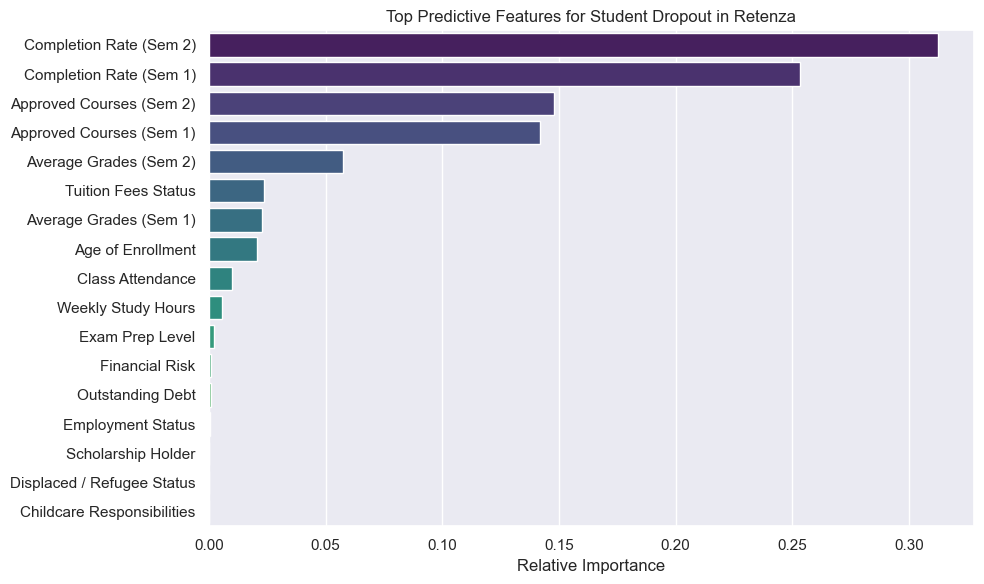

In [6]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Top Predictive Features for Student Dropout in Retenza')
sns.barplot(x=importances[indices], y=[FEATURE_DISPLAY_NAMES.get(FEATURES[i], FEATURES[i]) for i in indices], palette='viridis')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

## 6. Real-time Prediction and Intervention Logic
Below is an example of querying the trained model with a new student's data.

In [7]:
# Simulating an at-risk student input
sample_student = {
    'completion_rate_1': 0.45, 'completion_rate_2': 0.30,
    'approved_1sem': 3, 'approved_2sem': 1,
    'grade_1sem': 9.5, 'grade_2sem': 7.0,
    'tuition_fees': 0, 'financial_risk': 1,
    'scholarship': 0, 'debt': 1,
    'attendance': 2, 'study_hrs': 1,
    'exam_prep': 1, 'employed': 2,
    'childcare': 1, 'displaced': 0,
    'age': 25
}

feat_df = pd.DataFrame([sample_student])

# 1. Get Probability Score
prob = rf.predict_proba(feat_df)[0][1]
risk = 'High' if prob >= 0.6 else 'Medium' if prob >= 0.4 else 'Low'

print(f"Student Dropout Risk Score: {prob*100:.1f}%")
print(f"Risk Category: {risk}")


Student Dropout Risk Score: 100.0%
Risk Category: High
